Лаб №6. (энкодеры)

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)
torch.manual_seed(42)
import torch.optim as optim
import joblib

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_csv('/content/drive/MyDrive/paddydataset.csv')
print("Информация о датасете:")
df.head()

Информация о датасете:


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


Пункт 1. Генерация мошенеческих транзакций

In [8]:
print("ГЕНЕРАЦИЯ МОШЕННИЧЕСКИХ ТРАНЗАКЦИЙ В ДАТАСЕТЕ О РИСЕ")

df_fraud = df.copy()

yield_col = None
for col in df_fraud.columns:
    if 'yield' in col.lower() or 'Paddy' in col:
        yield_col = col
        break

if yield_col is None:
    numeric_cols = df_fraud.select_dtypes(include=[np.number]).columns
    yield_col = numeric_cols[-1]

print(f"\nЦелевая колонка (урожайность): '{yield_col}'")
print(f"Размер оригинального датасета: {len(df_fraud)}")

fraud_ratio = 0.05
n_fraud = int(len(df_fraud) * fraud_ratio)

print(f"\nПараметры генерации:")
print(f"  Процент мошеннических транзакций: {fraud_ratio*100}%")
print(f"  Количество мошеннических транзакций: {n_fraud}")

df_fraud['is_fraud'] = 0

np.random.seed(42)
fraud_indices = np.random.choice(len(df_fraud), n_fraud, replace=False)

original_values = df_fraud.loc[fraud_indices, yield_col].copy()

print(f"\nГенерация мошеннических транзакций...")

fraud_types = {
    'extreme_high': {'prob': 0.3, 'multiplier': (2.0, 5.0)},
    'extreme_low': {'prob': 0.3, 'multiplier': (0.1, 0.5)},
    'moderate_high': {'prob': 0.2, 'multiplier': (1.3, 2.0)},
    'random_shift': {'prob': 0.2, 'multiplier': (0.5, 1.5)}
}

for idx in fraud_indices:
    rand = np.random.random()
    cumsum = 0
    fraud_type = 'extreme_high'

    for ftype, params in fraud_types.items():
        cumsum += params['prob']
        if rand <= cumsum:
            fraud_type = ftype
            break

    original_value = df_fraud.loc[idx, yield_col]

    if fraud_type == 'extreme_high':
        multiplier = np.random.uniform(*fraud_types['extreme_high']['multiplier'])
        new_value = original_value * multiplier
        fraud_desc = f"экстремальное завышение (×{multiplier:.1f})"

    elif fraud_type == 'extreme_low':
        multiplier = np.random.uniform(*fraud_types['extreme_low']['multiplier'])
        new_value = original_value * multiplier
        fraud_desc = f"экстремальное занижение (×{multiplier:.1f})"

    elif fraud_type == 'moderate_high':
        multiplier = np.random.uniform(*fraud_types['moderate_high']['multiplier'])
        new_value = original_value * multiplier
        fraud_desc = f"умеренное завышение (×{multiplier:.1f})"

    else:
        shift_factor = np.random.uniform(*fraud_types['random_shift']['multiplier'])
        new_value = original_value * shift_factor
        fraud_desc = f"случайное смещение (×{shift_factor:.1f})"

    df_fraud.loc[idx, yield_col] = new_value
    df_fraud.loc[idx, 'is_fraud'] = 1

    if np.random.random() < 0.3:
        other_features = ['Seedrate(in Kg)', 'Urea_40Days', 'Trash(in bundles)']
        other_features = [f for f in other_features if f in df_fraud.columns]

        if other_features:
            other_feat = np.random.choice(other_features)
            original_other = df_fraud.loc[idx, other_feat]
            df_fraud.loc[idx, other_feat] = original_other * np.random.uniform(0.5, 2.0)
            fraud_desc += f", искажен {other_feat}"

print("РЕЗУЛЬТАТЫ ГЕНЕРАЦИИ")
print(f"Обычные транзакции: {(df_fraud['is_fraud'] == 0).sum()} ({(1-fraud_ratio)*100:.1f}%)")
print(f"Мошеннические транзакции: {(df_fraud['is_fraud'] == 1).sum()} ({fraud_ratio*100:.1f}%)")

ГЕНЕРАЦИЯ МОШЕННИЧЕСКИХ ТРАНЗАКЦИЙ В ДАТАСЕТЕ О РИСЕ

Целевая колонка (урожайность): 'Paddy yield(in Kg)'
Размер оригинального датасета: 2789

Параметры генерации:
  Процент мошеннических транзакций: 5.0%
  Количество мошеннических транзакций: 139

Генерация мошеннических транзакций...
РЕЗУЛЬТАТЫ ГЕНЕРАЦИИ
Обычные транзакции: 2650 (95.0%)
Мошеннические транзакции: 139 (5.0%)


/tmp/ipykernel_2627/4146365717.py:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6048.757748338694' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_fraud.loc[idx, yield_col] = new_value
/tmp/ipykernel_2627/4146365717.py:84: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '439.2035959525906' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_fraud.loc[idx, other_feat] = original_other * np.random.uniform(0.5, 2.0)
/tmp/ipykernel_2627/4146365717.py:84: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '47.23673359624865' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_fraud.loc[idx, other_feat] = original_other * np.rando

Пункт 2. Анализ

АНАЛИЗ ДАТАСЕТА С МОШЕННИЧЕСКИМИ ТРАНЗАКЦИЯМИ

Итоговый датасет:
  - Форма: (2789, 37)
  - Количество признаков: 37
  - Признаки: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)']...
  - Распределение классов:
    Обычные (0): 2650
    Мошеннические (1): 139
  - Процент мошенничества: 4.98%

Признаки для визуализации: ['Paddy yield(in Kg)', 'Seedrate(in Kg)']


/tmp/ipykernel_2627/3446585856.py:75: UserWarning: Glyph 26126 (\N{CJK UNIFIED IDEOGRAPH-660E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2627/3446585856.py:75: UserWarning: Glyph 26174 (\N{CJK UNIFIED IDEOGRAPH-663E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26126 (\N{CJK UNIFIED IDEOGRAPH-660E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26174 (\N{CJK UNIFIED IDEOGRAPH-663E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


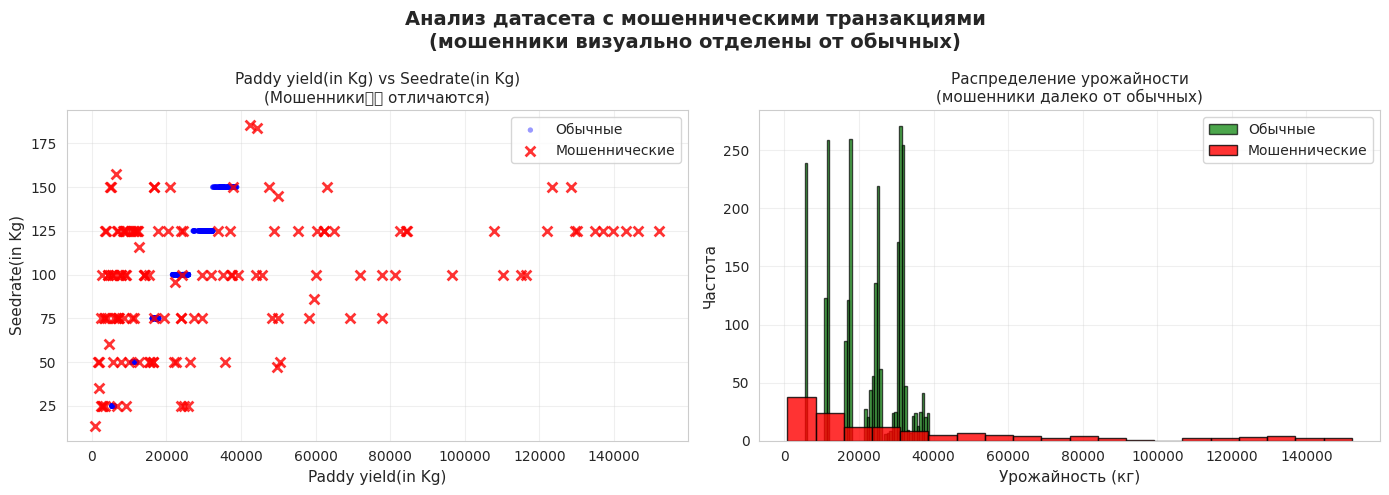

In [18]:
print("АНАЛИЗ ДАТАСЕТА С МОШЕННИЧЕСКИМИ ТРАНЗАКЦИЯМИ")

exclude_cols = ['is_fraud', 'class', 'Class']
feature_cols = [col for col in df_fraud.columns if col not in exclude_cols and df_fraud[col].dtype in ['float64', 'int64']]

X = df_fraud[feature_cols].values
y = df_fraud['is_fraud'].values

n_normal = (y == 0).sum()
n_fraud = (y == 1).sum()
n_features = X.shape[1]
feature_names = feature_cols

print(f"\nИтоговый датасет:")
print(f"  - Форма: {X.shape}")
print(f"  - Количество признаков: {n_features}")
print(f"  - Признаки: {feature_names[:5]}...")
print(f"  - Распределение классов:")
print(f"    Обычные (0): {n_normal}")
print(f"    Мошеннические (1): {n_fraud}")
print(f"  - Процент мошенничества: {n_fraud/(n_normal+n_fraud)*100:.2f}%")

yield_col = None
for col in feature_names:
    if 'yield' in col.lower() or 'Paddy' in col:
        yield_col = col
        break

visual_features = [yield_col] if yield_col else []

other_feats = ['Seedrate(in Kg)', 'Urea_40Days', 'Pest_60Day(in ml)', 'Trash(in bundles)']
for feat in other_feats:
    if feat in feature_names and feat != yield_col:
        visual_features.append(feat)

visual_features = visual_features[:2]
print(f"\nПризнаки для визуализации: {visual_features}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(visual_features) >= 2:
    feat1 = visual_features[0]
    feat2 = visual_features[1]

    normal_x = df_fraud[df_fraud['is_fraud'] == 0][feat1].values
    normal_y_vals = df_fraud[df_fraud['is_fraud'] == 0][feat2].values
    fraud_x = df_fraud[df_fraud['is_fraud'] == 1][feat1].values
    fraud_y_vals = df_fraud[df_fraud['is_fraud'] == 1][feat2].values

    axes[0].scatter(normal_x, normal_y_vals,
                    alpha=0.4, s=15, label='Обычные', c='blue', edgecolors='none')
    axes[0].scatter(fraud_x, fraud_y_vals,
                    alpha=0.8, s=50, label='Мошеннические', c='red', marker='x', linewidth=2)
    axes[0].set_xlabel(feat1, fontsize=11)
    axes[0].set_ylabel(feat2, fontsize=11)
    axes[0].set_title(f'{feat1} vs {feat2}\n(Мошенники明显 отличаются)', fontsize=11)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
if yield_col:
    normal_vals = df_fraud[df_fraud['is_fraud'] == 0][yield_col].values
    fraud_vals = df_fraud[df_fraud['is_fraud'] == 1][yield_col].values

    axes[1].hist(normal_vals, bins=50, alpha=0.7, label='Обычные',
                 color='green', edgecolor='black', density=False)
    axes[1].hist(fraud_vals, bins=20, alpha=0.8, label='Мошеннические',
                 color='red', edgecolor='black', density=False)
    axes[1].set_xlabel('Урожайность (кг)', fontsize=11)
    axes[1].set_ylabel('Частота', fontsize=11)
    axes[1].set_title('Распределение урожайности\n(мошенники далеко от обычных)', fontsize=11)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.suptitle('Анализ датасета с мошенническими транзакциями\n(мошенники визуально отделены от обычных)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nРазделение данных:")
print(f"  - Обучающая выборка: {X_train.shape}")
print(f"  - Тестовая выборка: {X_test.shape}")
print(f"  - Распределение в обучающей: {np.bincount(y_train.astype(int))}")
print(f"  - Распределение в тестовой: {np.bincount(y_test.astype(int))}")
X_train_normal = X_train[y_train == 0]
print(f"\nДанные для обучения автоэнкодера (только нормальные): {X_train_normal.shape}")


Разделение данных:
  - Обучающая выборка: (2231, 37)
  - Тестовая выборка: (558, 37)
  - Распределение в обучающей: [2120  111]
  - Распределение в тестовой: [530  28]

Данные для обучения автоэнкодера (только нормальные): (2120, 37)


Пункт 3. Создание автоэнкодера и обучение

ОБУЧЕНИЕ АВТОЭНКОДЕРА
Количество признаков: 37
Всего транзакций: 2789
Обычных (обучаем на них): 2650
Мошеннических (тест): 139
Обучающая выборка: 2120
Валидационная выборка: 530

Начало обучения...
Эпоха [10/100] - Train Loss: 0.056611, Val Loss: 0.013040
Эпоха [20/100] - Train Loss: 0.054443, Val Loss: 0.009246
Эпоха [30/100] - Train Loss: 0.036106, Val Loss: 0.006669
Эпоха [40/100] - Train Loss: 0.029808, Val Loss: 0.010140
Эпоха [50/100] - Train Loss: 0.029448, Val Loss: 0.009041
Эпоха [60/100] - Train Loss: 0.026088, Val Loss: 0.006072
Эпоха [70/100] - Train Loss: 0.031818, Val Loss: 0.005967
Эпоха [80/100] - Train Loss: 0.032413, Val Loss: 0.006220
Эпоха [90/100] - Train Loss: 0.026018, Val Loss: 0.010090
Эпоха [100/100] - Train Loss: 0.032812, Val Loss: 0.006768
Обучение завершено!


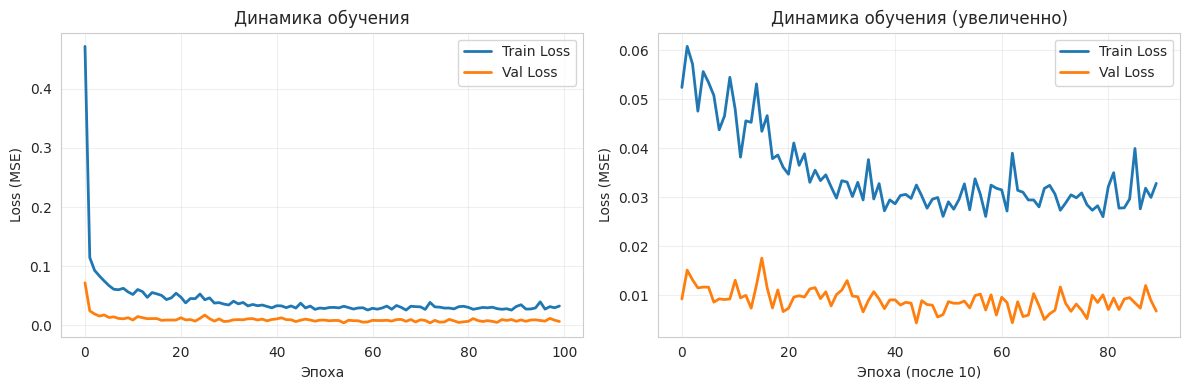

ОПРЕДЕЛЕНИЕ ПОРОГА
Статистика ошибок на обучающей выборке:
  Средняя: 0.006579
  Медиана: 0.004489
  95-й перцентиль (ПОРОГ): 0.022629
  Максимум: 0.029837


In [47]:


print("ОБУЧЕНИЕ АВТОЭНКОДЕРА")
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

exclude_cols = ['is_fraud', 'class', 'Class']
feature_cols = [col for col in df_fraud.columns if col not in exclude_cols and df_fraud[col].dtype in ['float64', 'int64']]

X = df_fraud[feature_cols].values
y = df_fraud['is_fraud'].values

print(f"Количество признаков: {len(feature_cols)}")
print(f"Всего транзакций: {len(X)}")
print(f"Обычных (обучаем на них): {(y == 0).sum()}")
print(f"Мошеннических (тест): {(y == 1).sum()}")

normal_data = X[y == 0]
fraud_data = X[y == 1]

scaler = StandardScaler()
normal_data_scaled = scaler.fit_transform(normal_data)
fraud_data_scaled = scaler.transform(fraud_data)
X_train, X_val = train_test_split(normal_data_scaled, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Валидационная выборка: {len(X_val)}")

input_dim = X.shape[1]
model = Autoencoder(input_dim)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

train_dataset = TensorDataset(torch.FloatTensor(X_train))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = TensorDataset(torch.FloatTensor(X_val))
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

num_epochs = 100
train_losses = []
val_losses = []

print("\nНачало обучения...")

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        data = batch[0]
        output = model(data)
        loss = criterion(output, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            data = batch[0]
            output = model(data)
            loss = criterion(output, data)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Эпоха [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

print("Обучение завершено!")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE)')
plt.title('Динамика обучения')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses[10:], label='Train Loss', linewidth=2)
plt.plot(val_losses[10:], label='Val Loss', linewidth=2)
plt.xlabel('Эпоха (после 10)')
plt.ylabel('Loss (MSE)')
plt.title('Динамика обучения (увеличенно)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ОПРЕДЕЛЕНИЕ ПОРОГА")

model.eval()
train_errors = []

with torch.no_grad():
    for batch in train_loader:
        data = batch[0]
        output = model(data)
        error = torch.mean((output - data) ** 2, dim=1)
        train_errors.extend(error.numpy())

threshold = np.percentile(train_errors, 95)

print(f"Статистика ошибок на обучающей выборке:")
print(f"  Средняя: {np.mean(train_errors):.6f}")
print(f"  Медиана: {np.median(train_errors):.6f}")
print(f"  95-й перцентиль (ПОРОГ): {threshold:.6f}")
print(f"  Максимум: {np.max(train_errors):.6f}")

In [48]:
model.eval()
test_dataset = TensorDataset(torch.FloatTensor(X_test))
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

reconstruction_errors = []

with torch.no_grad():
    for batch in test_loader:
        data = batch[0]
        output = model(data)
        error = torch.mean((output - data) ** 2).item()
        reconstruction_errors.append(error)

results_df = pd.DataFrame({
    'reconstruction_error': reconstruction_errors,
    'true_class': y_test
})

print(f"\nСтатистика ошибок реконструкции:")
print(results_df.groupby('true_class')['reconstruction_error'].describe())


Статистика ошибок реконструкции:
            count      mean       std       min       25%       50%       75%  \
true_class                                                                      
0           530.0  0.008565  0.007897  0.000701  0.003457  0.005659  0.009394   
1            28.0  0.315707  0.577639  0.003171  0.023436  0.065915  0.280033   

                 max  
true_class            
0           0.035001  
1           2.215180  


Пункт 4. Визуализация

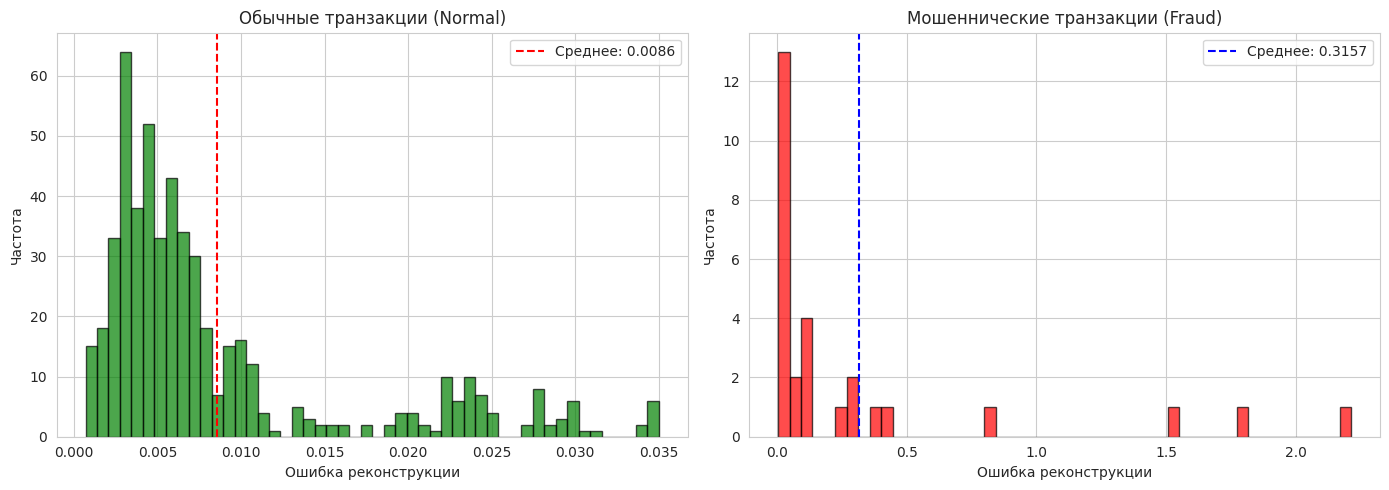

<Figure size 800x600 with 0 Axes>

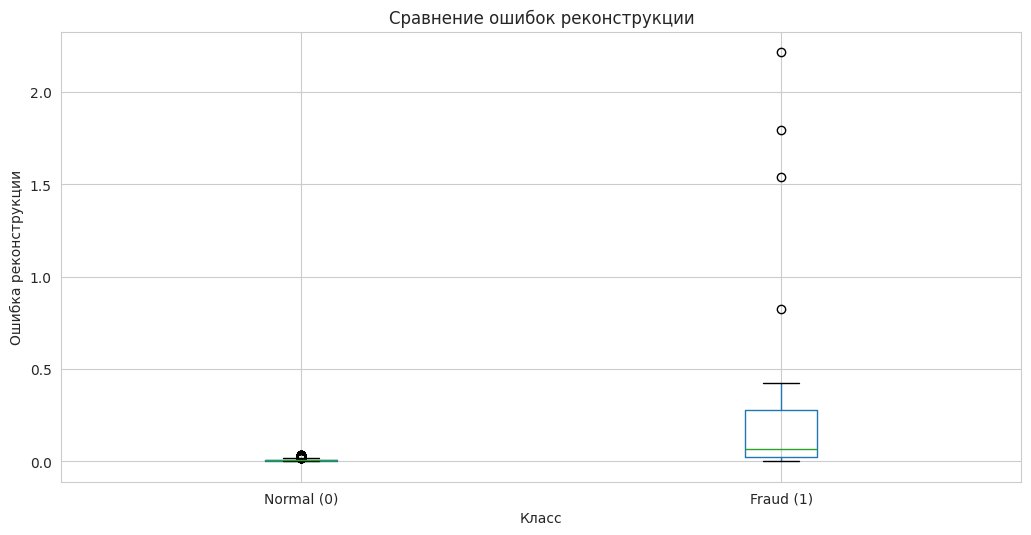

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_errors = results_df[results_df['true_class'] == 0]['reconstruction_error']
axes[0].hist(normal_errors, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0].set_title('Обычные транзакции (Normal)')
axes[0].set_xlabel('Ошибка реконструкции')
axes[0].set_ylabel('Частота')
axes[0].axvline(normal_errors.mean(), color='red', linestyle='--', label=f'Среднее: {normal_errors.mean():.4f}')
axes[0].legend()

fraud_errors = results_df[results_df['true_class'] == 1]['reconstruction_error']
axes[1].hist(fraud_errors, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Мошеннические транзакции (Fraud)')
axes[1].set_xlabel('Ошибка реконструкции')
axes[1].set_ylabel('Частота')
axes[1].axvline(fraud_errors.mean(), color='blue', linestyle='--', label=f'Среднее: {fraud_errors.mean():.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
results_df.boxplot(column='reconstruction_error', by='true_class')
plt.title('Сравнение ошибок реконструкции')
plt.suptitle('')
plt.xlabel('Класс')
plt.ylabel('Ошибка реконструкции')
plt.xticks([1, 2], ['Normal (0)', 'Fraud (1)'])
plt.show()


Выбранный порог: 0.027632


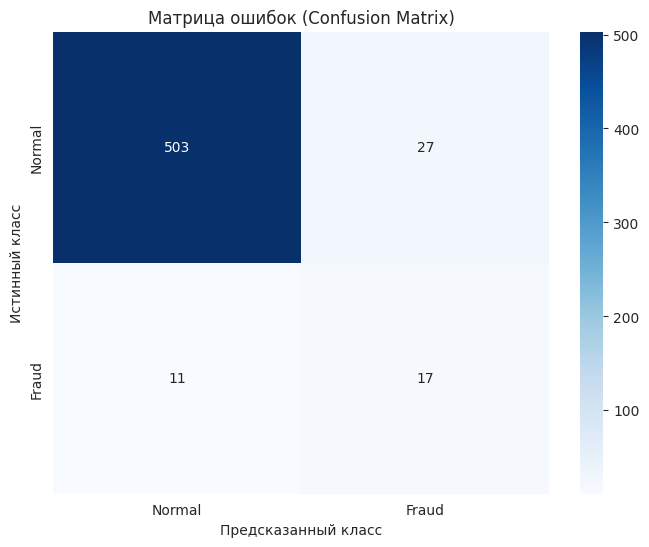

ОТЧЕТ О КЛАССИФИКАЦИИ
              precision    recall  f1-score   support

  Normal (0)       0.98      0.95      0.96       530
   Fraud (1)       0.39      0.61      0.47        28

    accuracy                           0.93       558
   macro avg       0.68      0.78      0.72       558
weighted avg       0.95      0.93      0.94       558



In [50]:
threshold = np.percentile(normal_errors, 95)
print(f"\nВыбранный порог: {threshold:.6f}")

y_pred = (results_df['reconstruction_error'] > threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

cm = confusion_matrix(results_df['true_class'], y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

print("ОТЧЕТ О КЛАССИФИКАЦИИ")
print(classification_report(results_df['true_class'], y_pred, target_names=['Normal (0)', 'Fraud (1)']))

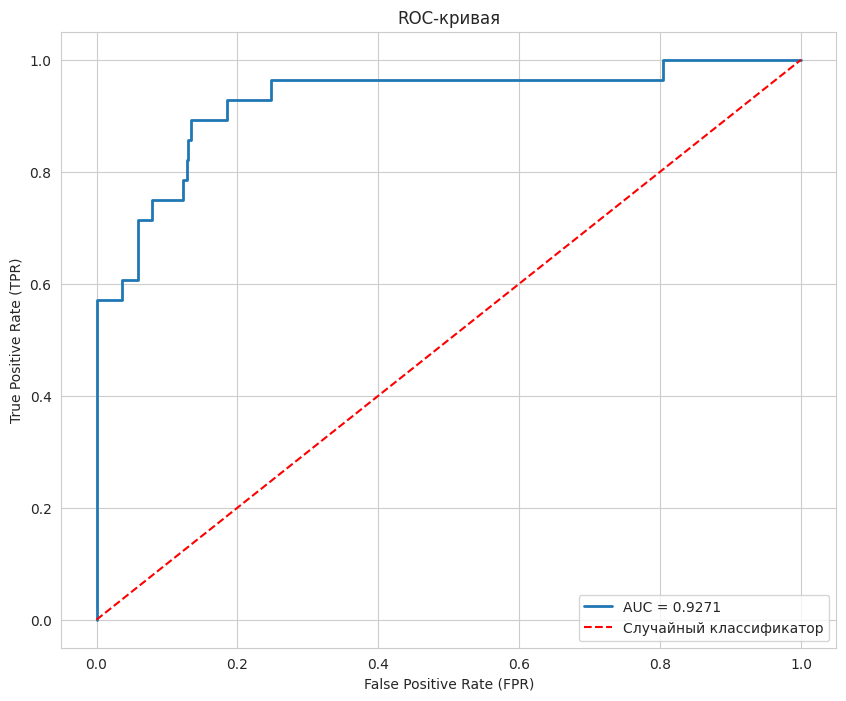

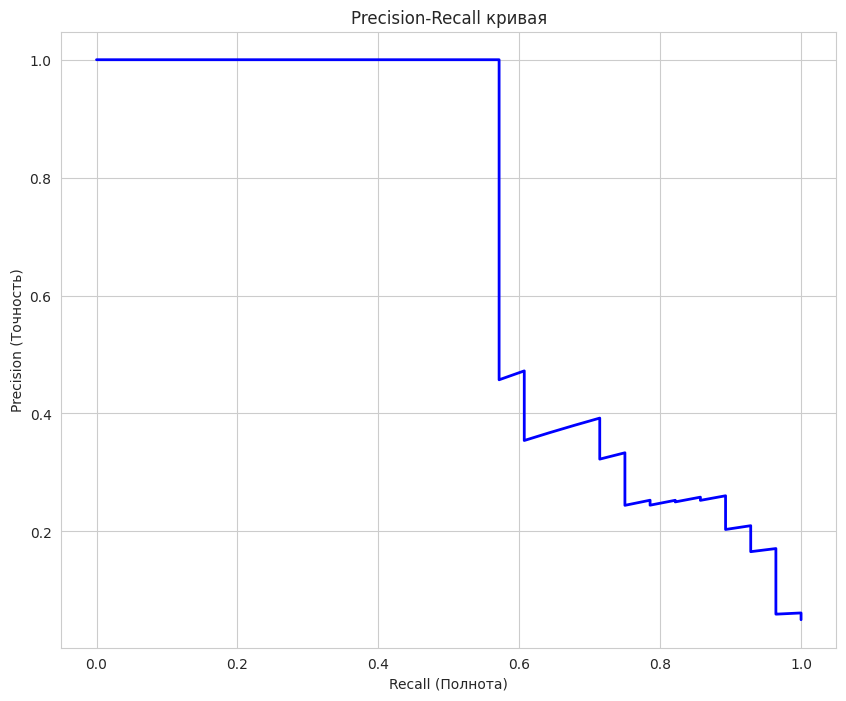

In [51]:
fpr, tpr, thresholds_roc = roc_curve(results_df['true_class'], results_df['reconstruction_error'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label='Случайный классификатор')
plt.title('ROC-кривая')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_pr = precision_recall_curve(results_df['true_class'], results_df['reconstruction_error'])

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, 'b-', linewidth=2)
plt.title('Precision-Recall кривая')
plt.xlabel('Recall (Полнота)')
plt.ylabel('Precision (Точность)')
plt.grid(True)
plt.show()

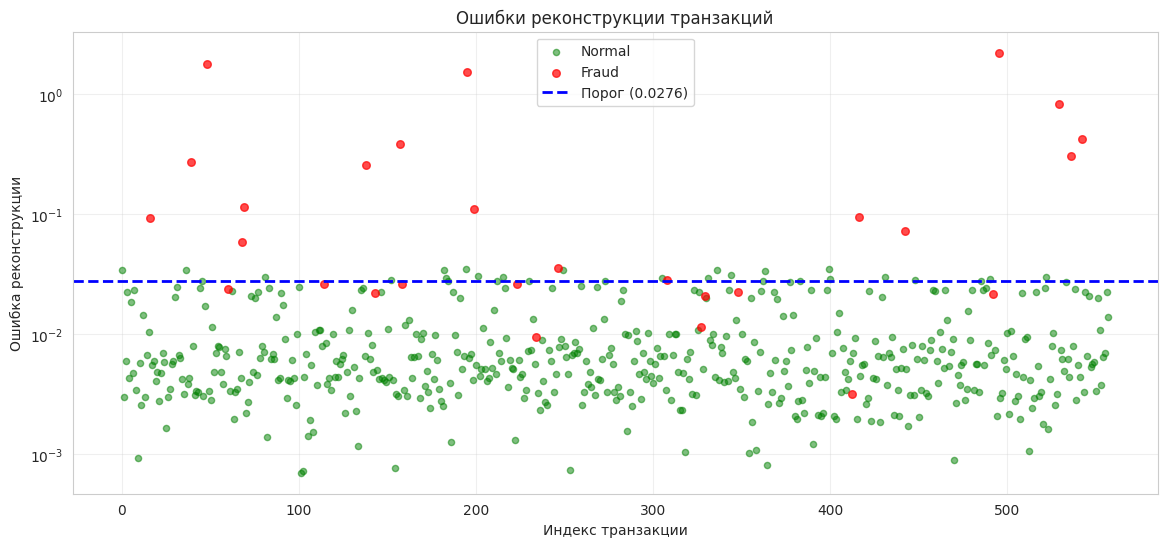

In [52]:
plt.figure(figsize=(14, 6))

normal_data_points = results_df[results_df['true_class'] == 0]
fraud_data_points = results_df[results_df['true_class'] == 1]

plt.scatter(normal_data_points.index, normal_data_points['reconstruction_error'],
            c='green', alpha=0.5, label='Normal', s=20)
plt.scatter(fraud_data_points.index, fraud_data_points['reconstruction_error'],
            c='red', alpha=0.7, label='Fraud', s=30)

plt.axhline(y=threshold, color='blue', linestyle='--',
            label=f'Порог ({threshold:.4f})', linewidth=2)

plt.title('Ошибки реконструкции транзакций')
plt.xlabel('Индекс транзакции')
plt.ylabel('Ошибка реконструкции')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

Пункт 5. Сохранение

In [53]:
print("ТЕСТИРОВАНИЕ МОДЕЛИ")

def predict_fraud(transaction, model, scaler, threshold):
    transaction_scaled = scaler.transform([transaction])
    transaction_tensor = torch.FloatTensor(transaction_scaled)
    model.eval()
    with torch.no_grad():
        reconstructed = model(transaction_tensor)
        error = torch.mean((reconstructed - transaction_tensor) ** 2).item()
    return error > threshold, error
test_normal = X[y == 0][:5]
test_fraud = X[y == 1][:5]

print("\nОбычные транзакции:")
for i, trans in enumerate(test_normal):
    is_fraud, error = predict_fraud(trans, model, scaler, threshold)
    status = "🔴 МОШЕННИЧЕСКАЯ" if is_fraud else "🟢 НОРМАЛЬНАЯ"
    print(f"  {i+1}. Ошибка: {error:.6f} -> {status}")

print("\nМошеннические транзакции:")
for i, trans in enumerate(test_fraud):
    is_fraud, error = predict_fraud(trans, model, scaler, threshold)
    status = "🔴 МОШЕННИЧЕСКАЯ" if is_fraud else "🟢 НОРМАЛЬНАЯ"
    print(f"  {i+1}. Ошибка: {error:.6f} -> {status}")

print("\n✅ Готово! Модель переобучена и должна правильно определять мошеннические транзакции.")

ТЕСТИРОВАНИЕ МОДЕЛИ

Обычные транзакции:
  1. Ошибка: 0.015267 -> 🟢 НОРМАЛЬНАЯ
  2. Ошибка: 0.008141 -> 🟢 НОРМАЛЬНАЯ
  3. Ошибка: 0.024709 -> 🟢 НОРМАЛЬНАЯ
  4. Ошибка: 0.017367 -> 🟢 НОРМАЛЬНАЯ
  5. Ошибка: 0.018027 -> 🟢 НОРМАЛЬНАЯ

Мошеннические транзакции:
  1. Ошибка: 0.338726 -> 🔴 МОШЕННИЧЕСКАЯ
  2. Ошибка: 0.161672 -> 🔴 МОШЕННИЧЕСКАЯ
  3. Ошибка: 0.123094 -> 🔴 МОШЕННИЧЕСКАЯ
  4. Ошибка: 0.045257 -> 🔴 МОШЕННИЧЕСКАЯ
  5. Ошибка: 0.247207 -> 🔴 МОШЕННИЧЕСКАЯ

✅ Готово! Модель переобучена и должна правильно определять мошеннические транзакции.
